# RT-DETR: аудит детекции бутылок, этикеток и переноса разметки

**Порядок работы пайплайна:**
`Восстановление данных` → `Кроп бутылки` → `Перенос Ground Truth (GT)` → `Кроп этикетки` → `Валидация ошибок` → `Расчёт метрик`.

**Ключевые архитектурные принципы:**
1. **Иммутабельность:** Исходные файлы никогда не меняются. Все артефакты и логи сохраняются в `data/derived/rtdetr_retrained_audit`.
2. **Воспроизводимость:** Полный пересчёт запускается скриптом `python scripts/audit_rtdetr_crops.py`. Запуск идемпотентен (его можно прерывать и возобновлять).
3. **Чистота метрик:** Готовые вырезки (кропы) сохраняются в JPEG (`quality=95`) без изменения исходных размеров, однако сами метрики качества рассчитываются **строго до** применения JPEG-сжатия.


In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

# --- Настройка окружения ---
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from wine_scanner.embed import load_image
from wine_scanner.embed.preprocess import PadToSquare
from scripts.audit_rtdetr_crops import summarize
from wine_scanner.detect.audit import transfer_box
from collections import defaultdict


OUT = ROOT / 'data/derived/rtdetr_retrained_audit'

# --- Загрузка результатов ---
records_text = (OUT / 'records.jsonl').read_text(encoding='utf-8').splitlines()
rows = [json.loads(s) for s in records_text]
good_rows = [r for r in rows if 'error' not in r]

# --- Вывод статистики ---
config_data = pd.Series(json.loads((OUT / 'config.json').read_text(encoding='utf-8')))
print("Конфигурация аудита:")
display(config_data.to_frame('Значение'))

print(f"\nСтатистика обработки:")
print(f"• Всего записей: {len(rows)}")
print(f"• Успешно обработано: {len(good_rows)}")
print(f"• Ошибок чтения/геометрии: {len(rows) - len(good_rows)}\n")

print("Сводные метрики:")
display(pd.DataFrame(summarize(rows)).T.rename(columns={0: 'Метрика'}))

g:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Конфигурация аудита:


,Значение
bottle,rtdetr:rtdetr_r18vd:bottle:bottle:t0.3:a0.05:c1
label,rtdetr:rtdetr_label_recrop_bf16:label:bottle:t...
label_sha256,7ccf4ac0f3e938f5b7baeea8b12c5d1891361a8f2c831b...
margin,0.08
device,cuda
version,1



Статистика обработки:
• Всего записей: 36759
• Успешно обработано: 36756
• Ошибок чтения/геометрии: 3

Сводные метрики:


,images,errors,bottle_fallbacks,label_fallbacks,annotated_images,gt_labels,selected_mean_iou_frame,selected_iou_ge_50,selected_iou_ge_75,gt_retained_ge_99,gt_lost,gt_clipped,label_crop_any_gt_retained_ge_99
test/frames_annotated,332.0,0.0,42.0,0.0,145.0,145.0,0.942917,0.993103,0.972414,1.000000,0.0,0.0,0.937931
train/frames_annotated,165.0,0.0,14.0,0.0,165.0,183.0,0.954150,1.000000,1.000000,0.956284,8.0,0.0,1.000000
test/labels_legacy_crops,164.0,0.0,9.0,0.0,132.0,132.0,0.938635,1.000000,1.000000,1.000000,0.0,0.0,0.984848
roboflow/test,309.0,0.0,14.0,0.0,309.0,319.0,0.934826,0.987055,0.961165,0.981191,1.0,5.0,0.938511
roboflow/train,5175.0,0.0,825.0,90.0,5175.0,12476.0,0.906126,0.961739,0.945121,0.902292,665.0,554.0,0.912271
train/labels_legacy_crops,169.0,0.0,11.0,2.0,153.0,153.0,0.925930,1.000000,0.980392,1.000000,0.0,0.0,0.947712
roboflow/valid,607.0,0.0,33.0,0.0,607.0,612.0,0.939078,0.990115,0.971993,0.986928,4.0,4.0,0.958814
catalog,2103.0,0.0,638.0,13.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN
eval,3.0,0.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN
own,256.0,0.0,24.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN


## 1. Целостность данных и происхождение разметки

При работе с сырыми архивами часто возникают проблемы с кодировками. Например, macOS использует разложенные (decomposed) Unicode-символы: визуально одинаковые буквы (например, `й`) могут иметь разные байтовые представления. 

**Скрипт распаковки реализует строгую нормализацию:**
1. Имена файлов принудительно приводятся к нормальной форме (NFC).
2. Выполняется сверка контрольных сумм (CRC). Отличающиеся файлы не перезаписываются.
3. Системные файлы и метаданные (resource forks) игнорируются.
4. Запрещенные символы (двоеточия в 12 именах) заменены на `_` с фиксацией в журнале соответствий.

**Интерпретация Ground Truth (разметки):**
* Название папки `frames_annotated` — это просто маркер источника, а **не гарантия** наличия разметки для каждого фото внутри.
* Изображения, не описанные в CSV, **не считаются** отрицательными примерами (мы их пропускаем).
* Старые директории `labels` содержат уже вырезанные фрагменты; метрики по ним считаются и показываются отдельно. Повторная обрезка старой вырезки не заменяет исходный полноразмерный кадр.


In [2]:
# Чтение логов распаковки
extraction_file = ROOT / 'data/archive_extraction.json'
extraction_data = json.loads(extraction_file.read_text(encoding='utf-8'))

print("Лог распаковки архива (без списка переименований):")
display(pd.Series(extraction_data).drop('renamed').to_frame('Значение'))

# Формирование инвентаризационной таблицы
inventory = pd.DataFrame([{
    'Группа': r['group'], 
    'Размечено (GT)': bool(r.get('gt_labels')),
    'Фоллбэк бутылки': r['bottle_fallback'],
    'Фоллбэк этикетки': r['label_fallback']
} for r in good_rows])

# Сводка по группам данных
summary_table = inventory.groupby('Группа').agg(
    Всего_изображений=('Размечено (GT)', 'size'),
    Есть_разметка=('Размечено (GT)', 'sum'),
    Сработал_фоллбэк_бутылки=('Фоллбэк бутылки', 'sum'),
    Сработал_фоллбэк_этикеток=('Фоллбэк этикетки', 'sum')
)

print("\nИнвентаризация датасетов:")
display(summary_table)

# Анализ ошибок
errors = [r for r in rows if 'error' in r]
if errors:
    print(f"\nДетализация ошибок ({len(errors)} шт.):")
    display(pd.DataFrame(errors))
else:
    print("\nОшибок чтения файлов или геометрии не обнаружено.")


Лог распаковки архива (без списка переименований):


,Значение
archive,data\Архив.zip
written,21192
identical,7
metadata_skipped,21739



Инвентаризация датасетов:


,Всего_изображений,Есть_разметка,Сработал_фоллбэк_бутылки,Сработал_фоллбэк_этикеток
Группа,,,,
catalog,2103,0,638,13
eval,3,0,2,0
own,256,0,24,1
roboflow/test,309,309,14,0
roboflow/train,5175,5175,825,90
roboflow/valid,607,607,33,0
synthetic,300,0,35,5
test,331,0,41,0
test/frames_annotated,332,145,42,0



Детализация ошибок (3 шт.):


,source,group,error
0,data/uploads/Derbent_Vino_szhat_webp_cb05d3331...,uploads,Image size (250122373 pixels) exceeds limit of...
1,data/uploads/Kommunalka_webp_e394ce9279.png,uploads,Image size (237831132 pixels) exceeds limit of...
2,data/uploads/Letnie_bezalkogolnye_koktejli_web...,uploads,cannot identify image file 'data\\uploads\\Let...


### Вывод раздела 1: Приоритет данных над моделью

Целостность архива и происхождение разметки проверяются **до** расчета любых метрик. Это критически важно: повреждённый или неразмеченный кадр нельзя молча классифицировать как «отрицательный пример», иначе это искусственно завысит False Positives. Такой подход позволяет отделить реальное качество детектора RT-DETR от шума и артефактов в исходных данных.

## 2. Эвристика выбора бутылки и определение ошибок

Алгоритм поиска целевой бутылки (Bottle Crop) работает по следующей логике:
1. **Кандидаты:** Отбираются рамки (bounding boxes) с confidence score ≥ 0.3.
2. **Фильтрация:** Бутылка должна занимать ≥ 5% площади кадра, а центр кадра должен находиться внутри её рамки.
3. **Ранжирование:** Если подходящих кандидатов несколько, они сортируются по формуле: `score × √(доля площади) × центральность`.
4. **Паддинг:** К выбранной рамке добавляется 8% отступа по краям для сохранения визуального контекста.
5. **Фоллбэк (Fallback):** Если подходящей бутылки нет, второй детектор (ищущий этикетку) получает **весь кадр** целиком. Это критически важное решение: на крупном плане этикетка может занимать всё пространство, и отсутствие детекции контура бутылки не должно ломать пайплайн.

**Специфика Single-Target задачи (поиск одного объекта):**
Фотографии часто делаются на полке магазина, где в кадр попадают десятки вин. Если соседние бутылки тоже размечены в базе (имеют GT-рамки), но при кропе целевой центральной бутылки они обрезаются — это **закономерное поведение**, а не провал алгоритма. Без явного указания целевого ID (`target_id`) нельзя автоматически доказать, что выбрана не та бутылка, поэтому такие метрики отсматриваются глазами и не занижают общую точность детектора.


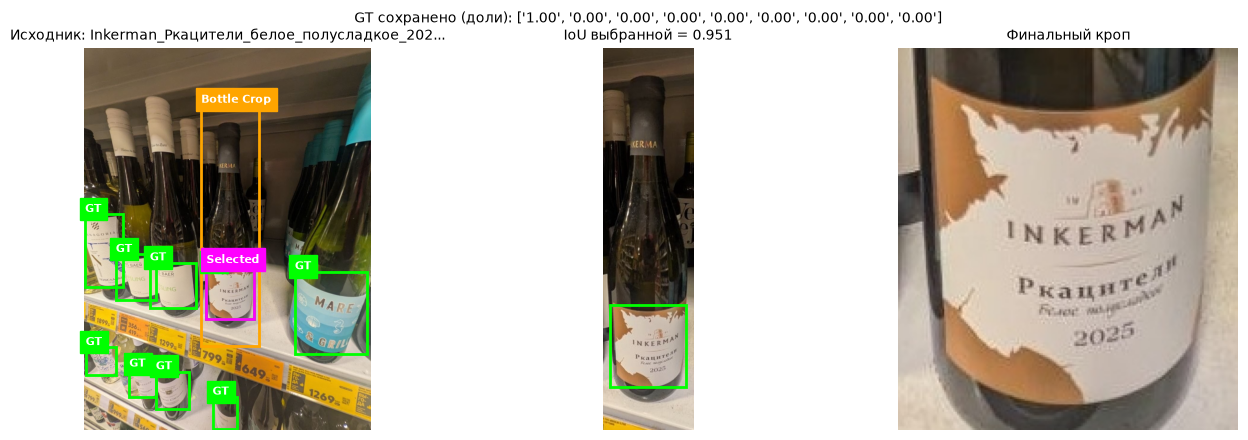

In [3]:
def draw_box(ax, box, color, text=None):
    """Отрисовка bounding box с опциональной текстовой плашкой."""
    x1, y1, x2, y2 = box
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=color, linewidth=2))
    if text: 
        # Добавляем фон для текста, чтобы он читался на пестрых этикетках
        ax.text(x1, max(0, y1 - 8), text, color='white', fontsize=8, 
                backgroundcolor=color, fontweight='bold')

def review(records, n=6):
    """Визуализация этапов: Исходник → Кроп бутылки → Кроп этикетки."""
    records = list(records)[:n]
    if not records:
        print('Подходящих случаев для визуализации не найдено.')
        return
        
    fig, axes = plt.subplots(len(records), 3, figsize=(14, 4.5 * len(records)), squeeze=False)
    
    for axs, r in zip(axes, records):
        # 1. Исходный кадр
        axs[0].imshow(load_image(r['source']))
        draw_box(axs[0], r['crop_rect'], 'orange', 'Bottle Crop')
        
        for b in r.get('gt_labels', []): 
            draw_box(axs[0], b, 'lime', 'GT')
            
        if r.get('selected_label_frame'): 
            draw_box(axs[0], r['selected_label_frame'], 'magenta', 'Selected')
            
        filename = Path(r['source']).name
        short_name = f"{filename[:40]}..." if len(filename) > 40 else filename
        axs[0].set_title(f"Исходник: {short_name}", fontsize=10)
        
        # 2. Кроп бутылки
        axs[1].imshow(load_image(r['bottle_crop']))
        for b in r.get('transferred_labels', []):
            if b: 
                draw_box(axs[1], b, 'lime')
                
        # Форматирование статистики
        retention = r.get('label_retention', [])
        retention_str = [f"{v:.2f}" for v in retention] if isinstance(retention, list) else retention
        iou = r.get('selected_label_iou_frame', 0)
        
        axs[1].set_title(f"GT сохранено (доли): {retention_str}\nIoU выбранной = {iou:.3f}", fontsize=10)
        
        # 3. Финальный кроп этикетки
        axs[2].imshow(load_image(r['label_crop']))
        axs[2].set_title('Финальный кроп', fontsize=10)
        
        for ax in axs: 
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

# Запускаем ревью для кадров, где часть площади Ground Truth (GT) была "потеряна" (retention < 0.99)
review_cases = [r for r in good_rows if r.get('group') == 'train/frames_annotated' 
                and any(v < 0.99 for v in r.get('label_retention', []))]

review(review_cases)


### Разбор краевых случаев и выводы раздела

**Цветовая легенда визуализации:**
* **Зелёный (Lime)** — Ground Truth (эталонная ручная разметка этикеток).
* **Оранжевый (Orange)** — Граница вырезки бутылки алгоритмом (Bottle Crop).
* **Пурпурный (Magenta)** — Итоговая выбранная целевая этикетка.

**Ручная проверка инцидентов с «потерей» разметки:**
В ходе автоматического тестирования была зафиксирована потеря восьми рамок. Ручной визуальный контроль показал, что **все восемь рамок** принадлежат фоновым/соседним бутылкам на одном групповом снимке полки (`Inkerman_Ркацители_белое_полусладкое_2025__far_01.jpg`). Центральная целевая этикетка при этом была успешно сохранена. Следовательно, это не является ошибкой целевого кропа.

**Архитектурный вывод:**
Первая модель (детекция бутылки) служит исключительно средством сохранения правильного контекста для второй модели (детекция этикетки). Фоллбэк гарантирует, что мы не потеряем данные при макросъемке. Истинная оценка качества пайплайна (ошибка) должна измеряться строго по финальной рамке этикетки в абсолютных координатах оригинального кадра.


## 3. Перенос рамок разметки (Ground Truth): проверка математики

При обрезке исходного изображения (crop) координаты эталонных рамок (bounding boxes) должны быть пересчитаны относительно новых границ. 

**Алгоритм переноса координат:**
1. **Пересечение:** Для исходной рамки `(x1, y1, x2, y2)` и области кропа `(left, top, right, bottom)` вычисляется площадь пересечения.
2. **Смещение:** Из координат пересечения вычитается отступ кропа `(left, top)`. 
3. **Масштабирование:** Поскольку сейчас кроп сохраняется без изменения физического размера (без resize), масштабный коэффициент равен 1. Если в будущем добавится resize или padding, координаты будут умножаться на соответствующий масштаб или сдвигаться на величину отступа.
4. **Ориентация:** EXIF-поворот изображения применяется *до* детекции, поэтому размеры кропа всегда строго сверены с GT. 

**Критическое правило:** Несовпадение размеров — это системная ошибка. Алгоритм не должен «молча» растягивать или искажать разметку, чтобы подогнать её под кроп.

**Метрика сохранения (Retention):**
`retained_fraction` показывает, какая доля площади исходной эталонной рамки осталась внутри кропа. Если рамка полностью исчезла (осталась за кадром), она не записывается как вырожденный COCO-box (с нулевой площадью), но факт её потери фиксируется в журнале.


In [4]:
# --- 1. Unit-тесты математики переноса ---

# Тест 1: Рамка полностью внутри кропа.
# Исходная рамка [20,30,60,70] внутри кропа [10,10,100,100]. 
# Ожидаем сдвиг на (-10, -10), сохранение площади 1.0
assert transfer_box([20, 30, 60, 70], [10, 10, 100, 100]) == ([10, 20, 50, 60], 1.0)

# Тест 2: Рамка частично обрезана границей кропа.
# Исходная рамка [0,0,20,20], кроп начинается с x=10 [10,0,30,20].
# Левая половина рамки отсекается. Ожидаем новые координаты [0,0,10,20] и сохранение площади 0.5
assert transfer_box([0, 0, 20, 20], [10, 0, 30, 20]) == ([0, 0, 10, 20], 0.5)

print("Математика переноса рамок (transfer_box): Unit-тесты пройдены успешно.\n")

# --- 2. Аудит частичной потери разметки ---

# Ищем кадры, где эталонная рамка была обрезана при кропе бутылки (retention < 0.99)
partial_loss_records = [
    {
        'Файл источника': r['source'], 
        'Доля сохранения GT (retention)': r['label_retention']
    } 
    for r in good_rows if any(v < 0.99 for v in r.get('label_retention', []))
]

loss_df = pd.DataFrame(partial_loss_records)

print(f"Кадры с частичной потерей площади разметки ({len(loss_df)} шт.):")
display(loss_df.head(30))

Математика переноса рамок (transfer_box): Unit-тесты пройдены успешно.

Кадры с частичной потерей площади разметки (528 шт.):


,Файл источника,Доля сохранения GT (retention)
0,data/train/frames_annotated/Inkerman_Ркацители...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,data/third-party datasets/wine-labels/test/202...,[0.5304518664047151]
2,data/third-party datasets/wine-labels/test/202...,[0.7991803278688525]
3,data/third-party datasets/wine-labels/test/202...,[0.8586666666666667]
4,data/third-party datasets/wine-labels/test/202...,[0.7196029776674938]
5,data/third-party datasets/wine-labels/test/lac...,"[1.0, 0.15, 0.0]"
6,data/third-party datasets/wine-labels/train/-_...,"[0.0, 0.21019108280254778, 1.0, 0.224358974358..."
7,data/third-party datasets/wine-labels/train/-_...,"[0.0, 0.12080536912751678, 1.0, 0.102040816326..."
8,data/third-party datasets/wine-labels/train/01...,[0.8311111111111111]
9,data/third-party datasets/wine-labels/train/01...,[0.9255079006772009]


### Вывод раздела 3 и требования к датасету

Математика переноса GT корректна только для физического пересечения с областью кропа: пиксели, утраченные за границей вырезки, не восстанавливаются арифметически. Именно поэтому показатель `retention` выводится явно, а не скрывается за усредненными метриками.

**Статус экспорта:**
Текущие сгенерированные папки `train`/`test` сохранены раздельно для предотвращения утечек. Однако этот экспорт **нельзя** считать готовым обучающим датасетом для следующей модели, пока не проведен ручной аудит неполной разметки (где retention < 1.0), очистка дубликатов и валидация негативных кадров (изображений без целевых объектов).

## 4. Ошибки этикетки: анализ худших случаев (Worst Cases)

Красивые и успешные кропы не доказывают устойчивость модели. Истинное качество системы выявляется при анализе худших случаев: бликов, сложных ракурсов и частичных перекрытий.

**Как мы оцениваем качество (IoU):**
* **Формула:** IoU (Intersection over Union) = площадь пересечения / площадь объединения рамок.
* **Координаты:** Сравнивается рамка, выбранная производственным алгоритмом (`pick`), в абсолютных координатах исходного кадра.
* **Пропуски:** Если детектор ничего не нашел (промолчал) — IoU = 0.
* **Множественные GT:** Если на кадре присутствует несколько эталонных рамок (GT), берется максимальный IoU с любой из них. Это означает, что текущая метрика оценивает способность детектора найти **какую-либо** этикетку, а не идентифицировать целевое вино. Чтобы измерять точность поиска конкретной бутылки, потребуется дополнительная target-разметка (ID цели).


Анализ худших случаев на TEST (отложенная выборка):


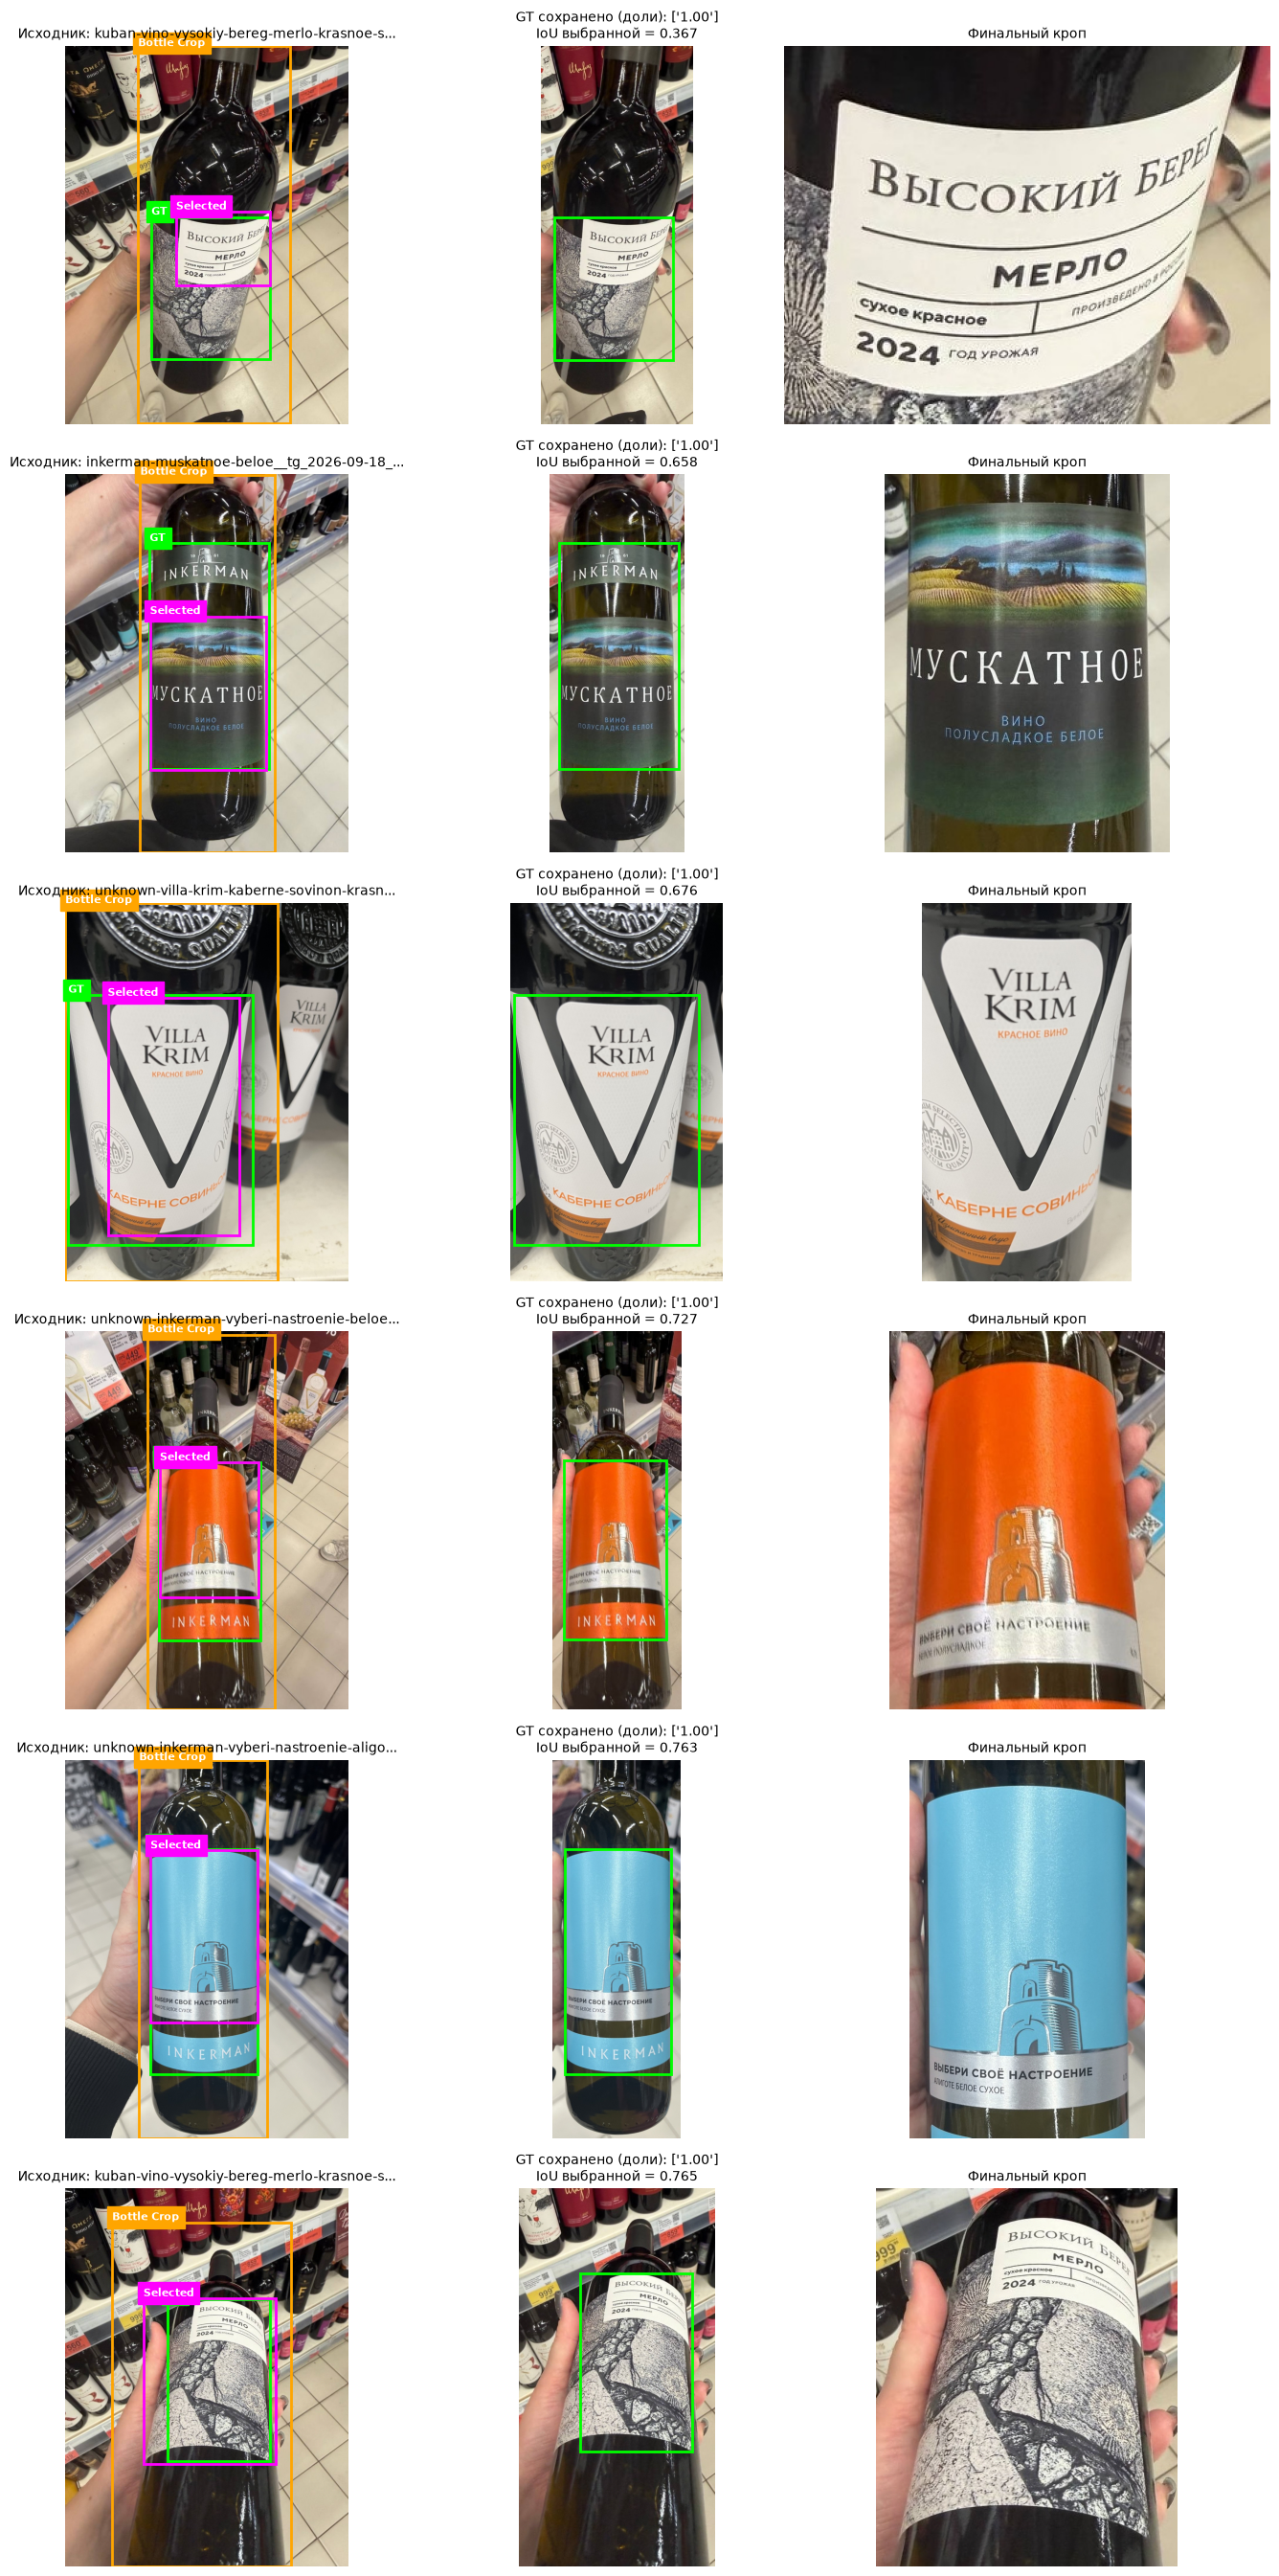


Анализ худших случаев на TRAIN (обучающая выборка):


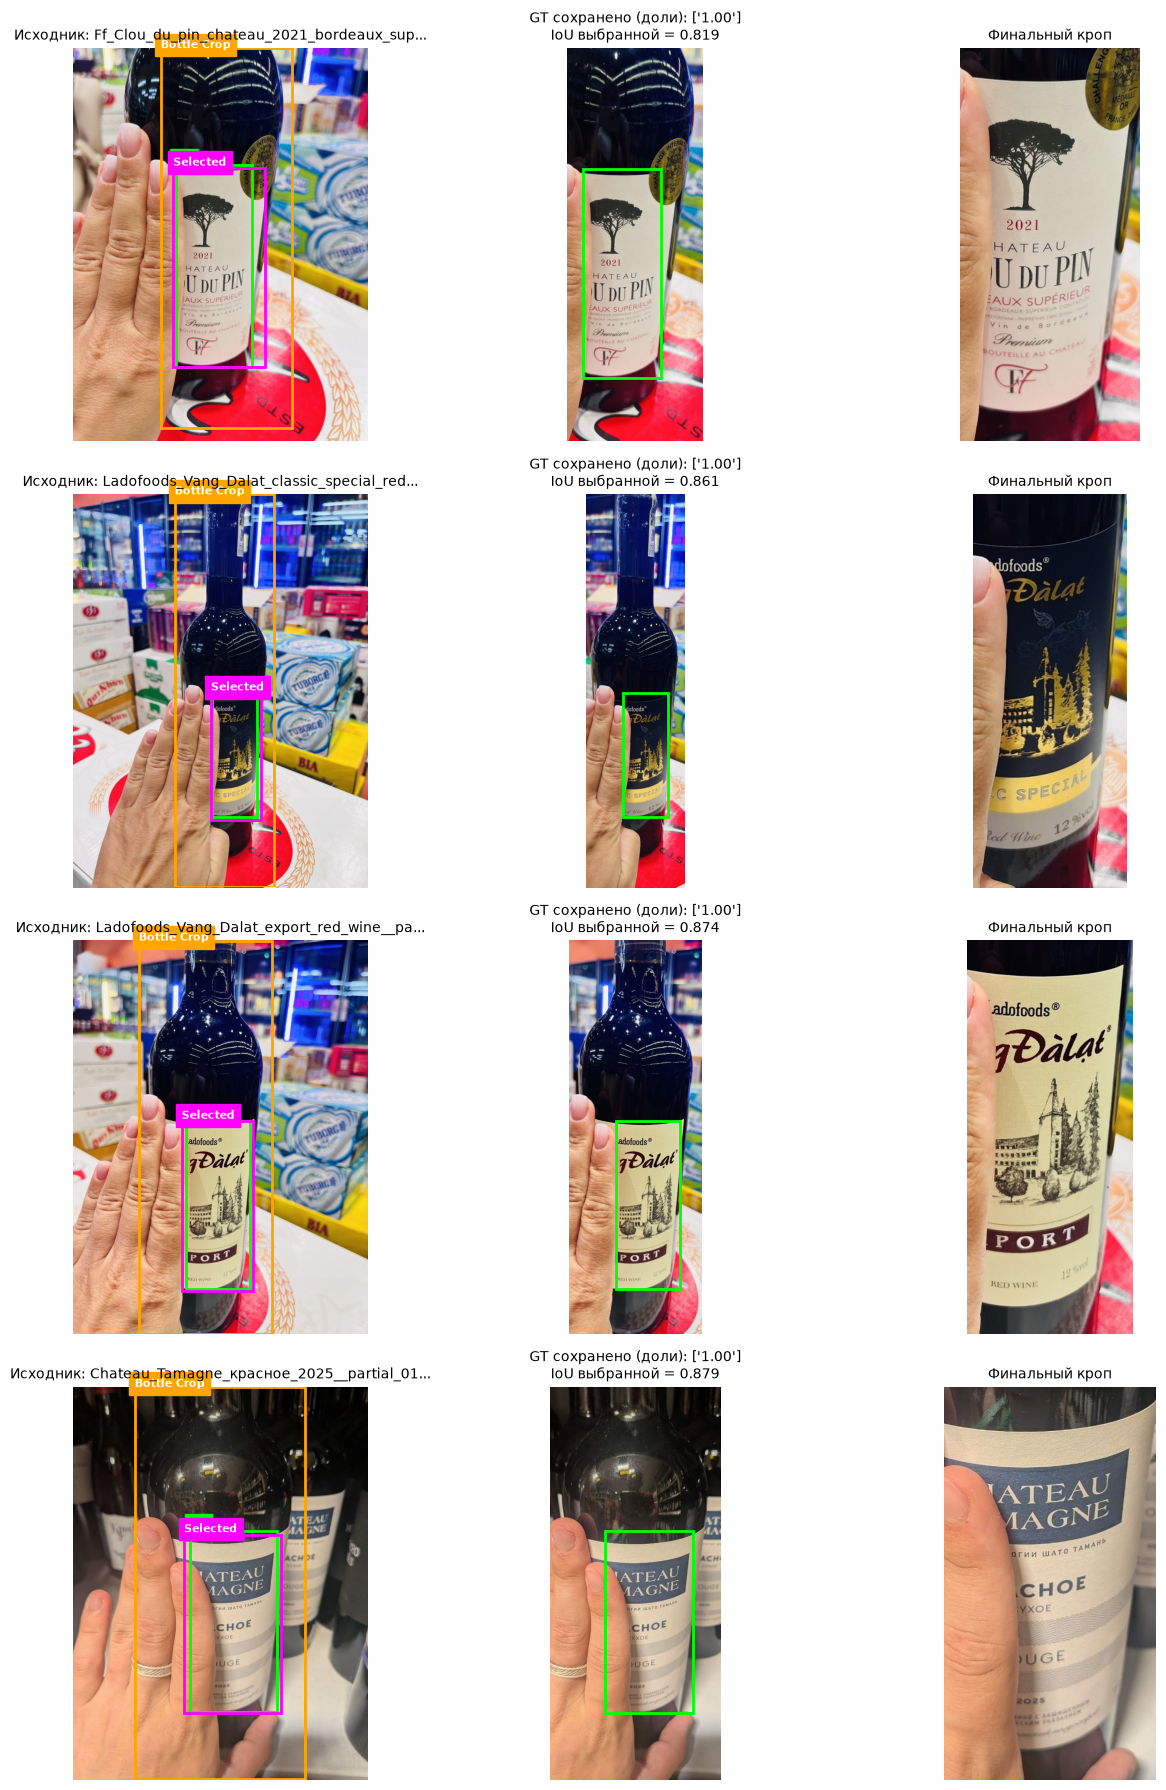

In [5]:
# Отбираем только те кадры, где физически присутствует эталонная разметка (gt_labels)
test_annotated = [r for r in good_rows if r.get('group') == 'test/frames_annotated' and r.get('gt_labels')]
train_annotated = [r for r in good_rows if r.get('group') == 'train/frames_annotated' and r.get('gt_labels')]

print("Анализ худших случаев на TEST (отложенная выборка):")
# Сортируем по IoU по возрастанию (от худших к лучшим) и берем топ-6
review(sorted(test_annotated, key=lambda r: r.get('selected_label_iou_frame', 0)), n=6)

print("\nАнализ худших случаев на TRAIN (обучающая выборка):")
# Берем топ-4 худших кейса из трейна
review(sorted(train_annotated, key=lambda r: r.get('selected_label_iou_frame', 0)), n=4)


### Разбор ошибок и выводы раздела

Контактные листы с низким IoU — это прямая очередь задач (backlog) для улучшения пайплайна.

**Что показывает визуальный аудит (Test):**
1. **Срабатывание фоллбэка:** Зафиксировано два случая, где детектор этикеток полностью промолчал, что привело к возврату всей бутылки целиком (fallback).
2. **Конфликт инструкций разметки («Инкерман Мускатное»):** Эталонная разметка (GT) объединяет основную бумажную этикетку и отдельную надпись бренда над ней в один большой блок. Детектор же логично выделяет только бумажную часть. 
   * **Решение:** Требуется строгая и единая инструкция для асессоров. Для бизнес-задачи (поиск/retrieval) главное — не потерять различающий текст, а не механически максимизировать IoU.

**Что показывает визуальный аудит (Train):**
* **Ошибки локализации цели (ложные срабатывания):** Четыре худших случая — это дальние бутылки на магазинных полках. Ограничение по минимальной площади на первой ступени (Bottle Crop) приводит к тому, что алгоритм бракует мелкие бутылки и передает на второй этап весь кадр. Вторая ступень (поиск этикетки) в этом хаосе цепляется за яркий текст на пивных коробках или соседних товарах.
* **Вектор развития:** В следующем эксперименте (на выборках train/valid) необходимо пересмотреть порог минимальной площади бутылки и целенаправленно добавить в обучение фотографии с трудными «шумными» фонами, чтобы отучить модель цепляться за посторонние ценники и коробки.

## 5. Метрики и архитектурные ограничения

В производственном пайплайне мы измеряем специфичные бизнес-метрики, а не классические академические показатели.

* **Доля IoU ≥ 0.75:** Показывает пригодность выбранной рамки для качественного кропа. Это **не mAP (Mean Average Precision)**.
* **Доля Fallback:** Измеряет поведение каскада при неудаче первого детектора (возврат всего кадра), а не метрику recall на неразмеченных бутылках.
* **Артефакты старого скрипта:** У старого скрипта обучения наблюдался `detection_rate = 1` при `threshold = 0`. Это особенность архитектуры DETR: без порога отсечения он всегда генерирует базовый набор object queries (гипотез). В текущем аудите действует строгий боевой порог `0.3`. Поэтому старые и новые метрики нельзя сравнивать в лоб.

**Вывод:** Текущий детектор RT-DETR оценивается по независимым группам вин на отложенном test-сете. Эти метрики аудита служат для анализа работы пайплайна, а не для автоматического выбора лучшего чекпоинта при обучении (для этого нужен mAP).


Сводная статистика по размеченным группам:


,images,errors,bottle_fallbacks,label_fallbacks,annotated_images,gt_labels,selected_mean_iou_frame,selected_iou_ge_50,selected_iou_ge_75,gt_retained_ge_99,gt_lost,gt_clipped,label_crop_any_gt_retained_ge_99
Группа датасета,,,,,,,,,,,,,
test/frames_annotated,332.0,0.0,42.0,0.0,145.0,145.0,0.942917,0.993103,0.972414,1.000000,0.0,0.0,0.937931
train/frames_annotated,165.0,0.0,14.0,0.0,165.0,183.0,0.954150,1.000000,1.000000,0.956284,8.0,0.0,1.000000
roboflow/test,309.0,0.0,14.0,0.0,309.0,319.0,0.934826,0.987055,0.961165,0.981191,1.0,5.0,0.938511
roboflow/train,5175.0,0.0,825.0,90.0,5175.0,12476.0,0.906126,0.961739,0.945121,0.902292,665.0,554.0,0.912271
roboflow/valid,607.0,0.0,33.0,0.0,607.0,612.0,0.939078,0.990115,0.971993,0.986928,4.0,4.0,0.958814


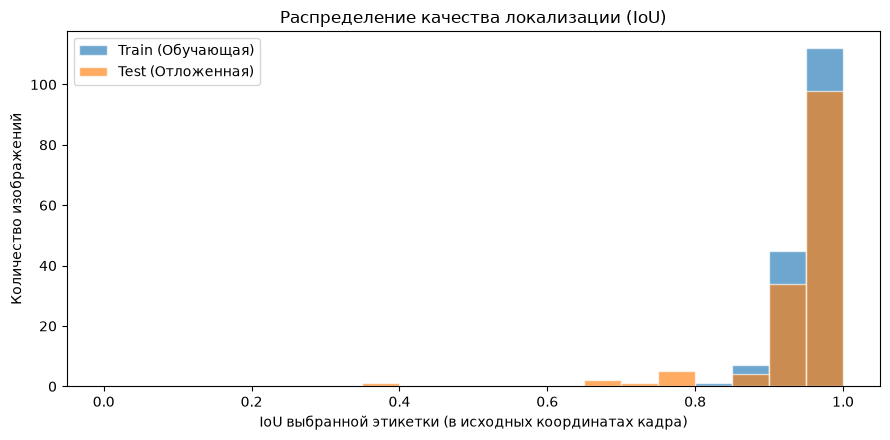

In [6]:
# Сводка только по размеченным датасетам (фреймы и roboflow)
summary_df = pd.DataFrame(summarize(rows)).T
annotated_groups = [g for g in summary_df.index if 'frames_annotated' in g or 'roboflow/' in g]

print("Сводная статистика по размеченным группам:")
display(summary_df.loc[annotated_groups].rename_axis("Группа датасета"))

# Настройка визуализации распределения IoU
fig, ax = plt.subplots(figsize=(9, 4.5))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Используем датасеты с разметкой из раздела 4
for name, subset, color in [('Train (Обучающая)', train_annotated, '#1f77b4'), 
                            ('Test (Отложенная)', test_annotated, '#ff7f0e')]:
    iou_values = [r.get('selected_label_iou_frame', 0) for r in subset]
    ax.hist(iou_values, bins=np.linspace(0, 1, 21), alpha=0.65, 
            label=name, color=color, edgecolor='white')

ax.set_xlabel('IoU выбранной этикетки (в исходных координатах кадра)')
ax.set_ylabel('Количество изображений')
ax.set_title('Распределение качества локализации (IoU)')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Дубликаты и статистическая независимость

Кадры, снятые в одной локации (серии одного вина), **нельзя** случайно делить между обучающей и тестовой выборкой. Почти идентичные ракурсы «утекут» в тест, и модель просто запомнит их, показав ложно-высокую точность.

1. **Разбиение по ID:** Данные сначала делятся по `wine_id`, и только потом строятся кропы. 
2. **Проверка хэшей:** Мы проверяем наличие точных побайтовых дубликатов (через SHA-256) между `train` и `test`. Нулевое значение здесь подтверждает отсутствие прямых утечек файлов, но не гарантирует отсутствие похожих ракурсов.
3. **Macro-Average и Bootstrap:** Чтобы вина, для которых снято 50 фото, не перевешивали в общей метрике вина с 1 фото, мы усредняем метрики *сначала внутри каждого вина*, а затем делаем Bootstrap-семплирование именно по независимым винам, а не по отдельным кадрам.

In [7]:
# --- 1. Проверка целостности манифеста ---
integrity = ROOT / 'data/derived/manifest_integrity.json'
if integrity.exists(): 
    print("Отчет о целостности манифеста:")
    display(json.loads(integrity.read_text(encoding='utf-8')))

# --- 2. Поиск абсолютных дубликатов (SHA-256 Leakage Check) ---
hashes = defaultdict(list)
for r in good_rows: 
    hashes[r['source_sha256']].append(r['source'])

cross_split = []
for digest, paths in hashes.items():
    if any('/train/' in p for p in paths) and any('/test/' in p for p in paths):
        cross_split.append({'sha256': digest, 'paths': paths})

print(f"\nКоличество точных побайтовых дублей между train и test: {len(cross_split)}")
if cross_split:
    display(pd.DataFrame(cross_split).head(20))

# --- 3. Bootstrap-оценка с группировкой по винам (Macro IoU) ---
rng = np.random.default_rng(2026)
by_wine = defaultdict(list)

# Группируем значения IoU по wine_id (извлекается из префикса имени файла)
for r in test_annotated:
    wine_id = Path(r['source']).name.split('__')[0]
    by_wine[wine_id].append(r.get('selected_label_iou_frame', 0))

# Вычисляем среднее IoU для каждого уникального вина
wine_means = np.array([np.mean(v) for v in by_wine.values()])

# Выполняем 2000 симуляций бутстрапа, выбирая *вино целиком*, а не отдельные кадры
boot = np.array([rng.choice(wine_means, len(wine_means), replace=True).mean() for _ in range(2000)])

metrics = pd.Series({
    'Количество уникальных вин в Test': len(wine_means),
    'Macro IoU (среднее по независимым винам)': wine_means.mean(),
    'Bootstrap 95% CI (Нижняя граница)': np.quantile(boot, 0.025),
    'Bootstrap 95% CI (Верхняя граница)': np.quantile(boot, 0.975)
}).round(4)

print("\nОценка доверительного интервала (Bootstrap by Wine):")
display(metrics.to_frame('Значение'))

Отчет о целостности манифеста:


{'train': {'images': 181, 'wines': 35},
 'test': {'images': 333, 'wines': 106},
 'overlap_wines': []}


Количество точных побайтовых дублей между train и test: 0

Оценка доверительного интервала (Bootstrap by Wine):


,Значение
Количество уникальных вин в Test,64.0000
Macro IoU (среднее по независимым винам),0.9439
Bootstrap 95% CI (Нижняя граница),0.9289
Bootstrap 95% CI (Верхняя граница),0.9565


## 7. Цвет полей (Padding): где он применяется и как выбирать честно

Важное уточнение по архитектуре пайплайна: детектор RT-DETR в текущей конфигурации меняет размер до 640×640 пикселей, при этом изначальный кроп бутылки **не заливается полями (no padding)**.
Приведение к квадрату применяется позже — непосредственно перед передачей финального кропа этикетки в модель-эмбеддер.

**Какие цвета сравнивали:**
* `(124, 116, 104)` — прежний цвет. Соответствует среднему значению ImageNet, что было оптимально для эмбеддера DINOv2.
* `(128, 128, 128)` — нейтральный серый цвет. Для модели SigLIP 2 (где mean=0.5) именно он является нейтральным входом.
* Белый и чёрный — крайние варианты для сравнения.

В эксперименте на валидационных винах из train (ноутбук 03, раздел 3) лучший результат показал белый цвет.

**Что используется сейчас (версия предобработки `label-square-v3`, с 23.09):** квадрат этикетки вырезается из исходного кадра, а не из кропа бутылки, поэтому вокруг этикетки остаётся настоящий фон фотографии. Заливка нужна только тогда, когда квадрат выходит за границы кадра, и её цвет — медиана пикселей по краю кадра, то есть цвет фона снимка. У каталожных эталонов это обычно белый фон. Картинки ниже показывают варианты, которые сравнивались.

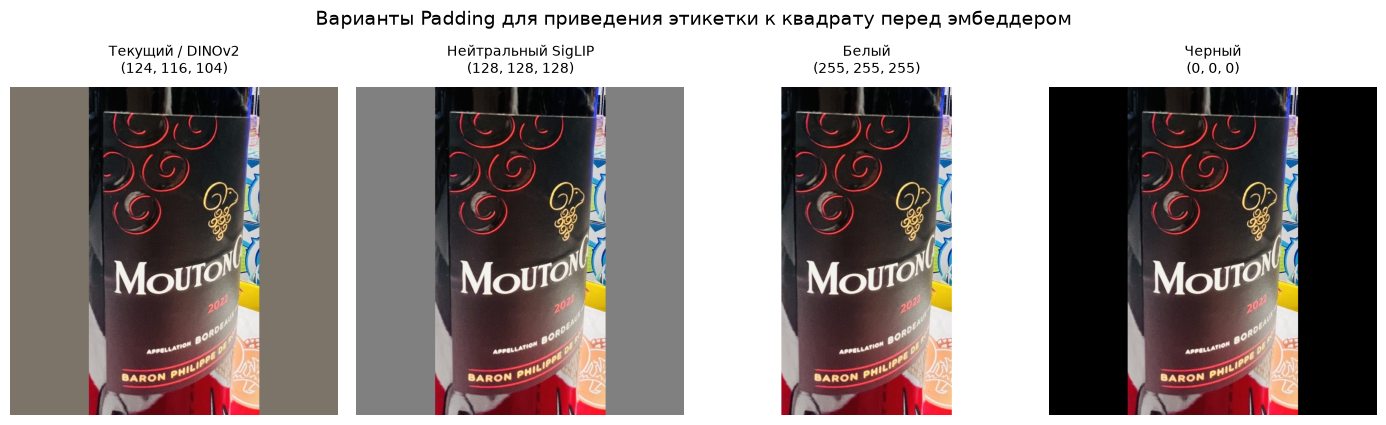

In [8]:
# Задаем 4 варианта цвета полей (RGB) для визуального сравнения
padding_colors = {
    'Текущий / DINOv2\n(124, 116, 104)': (124, 116, 104),
    'Нейтральный SigLIP\n(128, 128, 128)': (128, 128, 128),
    'Белый\n(255, 255, 255)': (255, 255, 255),
    'Черный\n(0, 0, 0)': (0, 0, 0)
}

# Берем первый доступный размеченный кадр из обучающей выборки
demo_record = next(iter(train_annotated))

if 'label_crop' in demo_record and Path(demo_record['label_crop']).exists():
    original_crop = load_image(demo_record['label_crop'])
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    
    for ax, (name, color) in zip(axes, padding_colors.items()):
        # Применяем паддинг до квадрата с заданным цветом
        padder = PadToSquare(fill=color)
        padded_img = padder(original_crop)
        
        ax.imshow(padded_img)
        ax.axis('off')
        ax.set_title(name, fontsize=10, pad=10)

    plt.suptitle('Варианты Padding для приведения этикетки к квадрату перед эмбеддером', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Изображение финального кропа не найдено для демонстрации.")

### Правильная методология тестирования (Ablation Study)

Изменить цвет padding только для пользовательского запроса (на лету), оставив старый FAISS-индекс каталога — **грубая методологическая ошибка**. Векторы будут лежать в разных пространствах.

Чтобы честно выбрать лучший цвет (например, доказать превосходство серого цвета SigLIP), необходимо провести строгий эксперимент:
1. Пересобрать эмбеддинги всего каталога (Reference) отдельно для каждого из 4 цветов.
2. Жёстко зафиксировать веса моделей, алгоритм кропа и разбиение на train/valid.
3. Сравнить метрики поиска (`Recall@1`, `Recall@5`, `Recall@50`) на **валидационных винах** (train-validation ablation).
4. Выбрать победителя и **только один раз** измерить финальное качество на отложенном `holdout` сете, чтобы избежать переобучения под метрику.

**Вывод раздела:** 
Цвет полей имеет значение исключительно при приведении финального label crop к квадрату. В текущем production-индексе используется математически согласованная настройка для запроса и эталона. Менять её можно только через полный цикл переиндексации базы и валидации.

## 8. Сквозной поиск и план экспериментов

Этот ноутбук проверяет только детекцию и кропы. Бизнес-метрики сквозного поиска (доля верных ответов, точность, покрытие, доля ложных приёмов незнакомых вин) считаются по актуальному индексу и решающему слою в ноутбуках 06 (обучение решающего слоя) и 08 (разбор ошибок на тесте).

**Защита от рассинхронизации данных:**
Для старых `.pt`-индексов фабрика классов выдает жесткую ошибку. Это архитектурное решение: нельзя незаметно поменять алгоритм кропа только для входящих запросов, оставив старые кропы в индексной базе (это сломает векторное пространство).
Правильный порядок действий: полная пересборка индекса с RT-DETR, затем запуск бенчмарка:
`uv run python eval/platform_benchmark.py --tag <метка прогона>`

### Дорожная карта (Next Steps)

Мы не переобучаем модель до полной фиксации текущего бейзлайна (baseline). План следующий:
1. **Сбор Target-GT:** Добавить целевые ID для оценки точности поиска конкретных вин, а не просто факта детекции любой этикетки.
2. **Отладка бейзлайна:** Исправить причины появления худших кропов на выборках `train`/`valid` (решить проблему с фоллбэком на мелких бутылках).
3. **Обучение:** Дообучать систему (включая CatBoost) уже на новых, исправленных бутылочных кропах.
4. **Единообразие:** Итоговый бенчмарк и production API должен обслуживать один и тот же инстанс `WineScanner`.

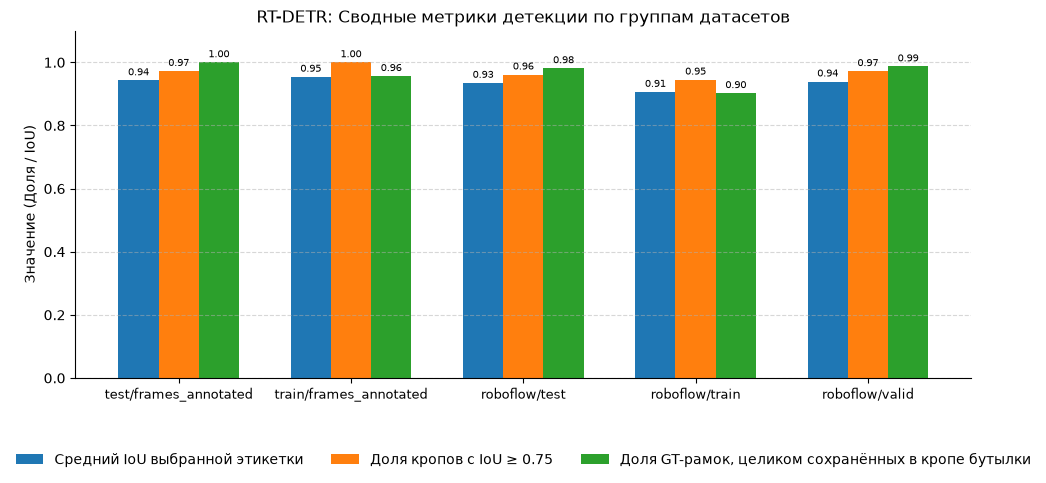

In [ ]:
# Названия колонок из summarize() и их подписи на графике
metric_columns = {
    'selected_mean_iou_frame': 'Средний IoU выбранной этикетки',
    'selected_iou_ge_75': 'Доля кропов с IoU ≥ 0.75',
    'gt_retained_ge_99': 'Доля GT-рамок, целиком сохранённых в кропе бутылки',
}

# Берём только размеченные группы из раздела 5: у остальных метрик нет
plot_df = (summary_df.loc[annotated_groups, list(metric_columns)]
           .astype(float).rename(columns=metric_columns))

# Настройка визуализации
fig, ax = plt.subplots(figsize=(11, 5))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Построение графика
plot_df.plot.bar(
    ax=ax,
    ylim=(0, 1.1),
    color=['#1f77b4', '#ff7f0e', '#2ca02c'],
    title='RT-DETR: Сводные метрики детекции по группам датасетов',
    width=0.7
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=7)

ax.set_ylabel('Значение (Доля / IoU)')
ax.set_xlabel('')
plt.xticks(rotation=0, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

### Финальные выводы и стратегия принятия решений

**Архитектура утверждена:** 
Актуальный сквозной путь работает по цепочке `RT-DETR` → `SigLIP 2` → `PaddleOCR` → `XFeat` → `CatBoost`.

**Главный нерешенный риск — Open-world False Accept:**
Система всё ещё может ложно принять совершенно незнакомое вино за ближайшего соседа по базе. Именно поэтому для следующего эксперимента критически важно собрать **новую независимую validation-группу реальных незнакомых вин** (о чем говорилось в начале документа). Только на свежих, неизвестных данных мы сможем корректно откалибровать пороги механизма отказа (open-world rejection).

**Философия релиза:**
Табличные метрики и графики (как выше) отвечают на вопрос *«сколько и где»*. Контактные листы с ошибками (из раздела 4) отвечают на вопрос *«почему именно»*. Менять production-модель разрешается **только после проверки обеих перспектив**: сухие агрегированные цифры всегда должны подтверждаться визуальным аудитом конкретных инцидентов.